# Lightweight Malaria Cell Classification using Histogram Features and Random Forests

**Author:** Please Lukau  
**Institution:** University of Illinois Chicago

This notebook accompanies the paper *A Systematic Investigation of Lightweight Color Histogram Representations for Malaria Cell Classification*.

Running this notebook from top to bottom reproduces every experiment and figure presented in the manuscript. It is intended to serve as the paper's executable supplementary material.

**Related resources**

- [Paper](https://example.com/replace-with-paper-url)
- [Official NIH/NLM malaria dataset](https://data.lhncbc.nlm.nih.gov/public/Malaria/)
- [GitHub repository](https://github.com/your-username/malaria-lightweight-detection)

## 1. Project Overview

This notebook implements a complete classical machine-learning pipeline for classifying malaria-infected and uninfected cell images from the NIH malaria dataset. Each image is resized and converted to RGB before a compact, normalized color-histogram representation is extracted in either RGB or HSV color space. A Random Forest classifier is trained on these features and evaluated using accuracy, precision, recall, F1-score, ROC/AUC, five-fold cross-validation, a confusion matrix, sensitivity, and specificity. Feature importance and PCA provide complementary interpretation and visualization.
```text
Cell images  -> Image preprocessing -> RGB/HSV histograms -> Random Forest -> Metrics and validation -> Publication figures
```

### Requirements

- Python 3.11
- OpenCV
- NumPy
- scikit-learn
- Matplotlib
- Seaborn
- tqdm

### Expected Runtime

| Mode | Approximate runtime |
|---|---:|
| Small dataset | 30 seconds |
| Full dataset with cached features | 1 minute |
| Full dataset with feature extraction | 20–30 minutes, depending on hardware |

Cross-validation and figure generation are included in these estimates. Actual runtime depends on CPU speed, storage, and the number of parallel workers available.

### Expected Outputs

After running the notebook, you will obtain:

- ✓ ROC curve
- ✓ Confusion matrix
- ✓ Feature-importance plot
- ✓ PCA visualization
- ✓ Saturation-histogram comparison
- ✓ Saved feature cache
- ✓ Final classification and validation metrics

### Reproducing the Paper

Use the following configuration to reproduce the reported experiment exactly:

```python
FEATURE_TYPE = "HSV"
NUM_BINS = 8
USE_SMALL_DATASET = False
```

Set `RECOMPUTE_FEATURES = False` when the matching full-dataset cache files are available. For a clean reproduction without cache files, leave it as `True`; the resulting experiment is identical but takes longer. `FEATURE_TYPE` is the single source of truth, so a separate `FEATURE_SET` variable is intentionally unnecessary.

## 2. Notebook Roadmap

1. Import libraries
2. Set random seeds
3. Configure the experiment
4. Set up and inspect the dataset
5. Select the small or full dataset
6. Display example images
7. Preprocess images
8. Extract histogram features
9. Build and cache the feature dataset
10. Split the data and name the features
11. Define and train the Random Forest
12. Evaluate performance
13. Generate figures
14. Report storage requirements and final results

## 3. Import Libraries

All dependencies used throughout the notebook are imported in one place.

In [24]:
import os
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import cross_val_score, train_test_split

## 4. Set Random Seeds

Fixed seeds make dataset sampling, image ordering, the train/test split, and model fitting repeatable across runs.

In [25]:
random.seed(42)
np.random.seed(42)

## 5. Configuration

Every adjustable experiment parameter is defined below. The defaults reproduce the full HSV experiment reported in the paper. Set `RECOMPUTE_FEATURES` to `False` only after the matching cache files have been generated.

In [26]:
DATASET_PATH = "/content/drive/My Drive/Colab Notebooks/ECE407_Malaria_Project/malaria_dataset"
IMAGE_SIZE = (64, 64)
FEATURE_TYPE = "HSV"
USE_SMALL_DATASET = False
SMALL_DATASET_SIZE = 500
RECOMPUTE_FEATURES = True
NUM_BINS = 8
TEST_SIZE = 0.20
RANDOM_STATE = 42
N_ESTIMATORS = 200
CV_FOLDS = 5
INFERENCE_RUNS = 1000
FIGURE_DPI = 300
OUTPUT_DIR = "."

if FEATURE_TYPE not in {"RGB", "HSV"}:
    raise ValueError("FEATURE_TYPE must be either 'RGB' or 'HSV'.")

## 6. Dataset Setup

The NIH malaria dataset is organized into `Parasitized` and `Uninfected` folders. In Google Colab, the cell mounts Google Drive when necessary. It then loads the PNG paths from both class folders and reports the class counts.

In [27]:
if not os.path.isdir(DATASET_PATH):
    try:
        from google.colab import drive

        drive.mount("/content/drive")
    except ImportError:
        pass

infected_folder = os.path.join(DATASET_PATH, "Parasitized")
uninfected_folder = os.path.join(DATASET_PATH, "Uninfected")

if not os.path.isdir(infected_folder) or not os.path.isdir(uninfected_folder):
    raise FileNotFoundError(
        "Dataset folders were not found. Set DATASET_PATH in the configuration cell."
    )

infected_images = [
    os.path.join(infected_folder, name)
    for name in os.listdir(infected_folder)
    if name.lower().endswith(".png")
]
uninfected_images = [
    os.path.join(uninfected_folder, name)
    for name in os.listdir(uninfected_folder)
    if name.lower().endswith(".png")
]

print(f"Number infected: {len(infected_images)}")
print(f"Number uninfected: {len(uninfected_images)}")

Number infected: 13779
Number uninfected: 13779


## 7. Small vs. Full Dataset

Small-dataset mode samples an equal number of images from each class for quick debugging. The full dataset is the default and is required to reproduce the paper results.

In [28]:
if USE_SMALL_DATASET:
    if SMALL_DATASET_SIZE > min(len(infected_images), len(uninfected_images)):
        raise ValueError("SMALL_DATASET_SIZE exceeds the available images per class.")
    infected_images = random.sample(infected_images, SMALL_DATASET_SIZE)
    uninfected_images = random.sample(uninfected_images, SMALL_DATASET_SIZE)
    dataset_mode = "small"
else:
    dataset_mode = "full"

print(f"Dataset mode: {dataset_mode}")
print(f"Infected images used: {len(infected_images)}")
print(f"Uninfected images used: {len(uninfected_images)}")

Dataset mode: full
Infected images used: 13779
Uninfected images used: 13779


## 8. Image Preprocessing

Each image is read from disk, resized to 64 × 64 pixels, and converted from OpenCV's BGR order to RGB. Consistent dimensions make feature extraction uniform, while RGB conversion establishes the expected color representation for both RGB and HSV features.

In [29]:
def preprocess_image(path):
    """Read an image path and return a resized RGB array, or None if unreadable."""
    image = cv2.imread(path)
    if image is None:
        return None
    image = cv2.resize(image, IMAGE_SIZE)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

## 9. Display Example Images

One preprocessed image from each class provides a visual check that the dataset can be read and that resizing and color conversion are correct.

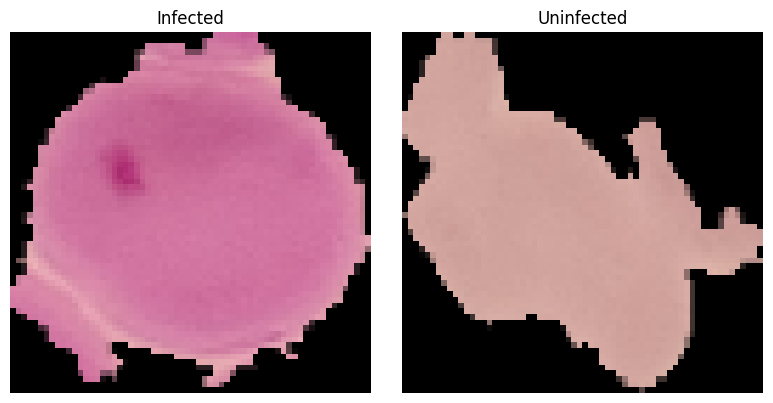

In [30]:
sample_infected = preprocess_image(infected_images[0])
sample_uninfected = preprocess_image(uninfected_images[0])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for axis, image, title in zip(
    axes,
    [sample_infected, sample_uninfected],
    ["Infected", "Uninfected"],
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

## 10. Feature Extraction

Color histograms summarize the distribution of pixel intensities without requiring a large learned representation. Eight bins per channel provide a compact 24-dimensional vector while retaining useful color information. Each channel histogram is normalized so its magnitude is not driven by raw pixel count. RGB describes red, green, and blue intensity directly; HSV separates hue and saturation from brightness, which can make chromatic differences between infected and uninfected cells easier to isolate.

In [31]:
def extract_rgb_histogram(image, bins=NUM_BINS):
    """Return concatenated, normalized RGB histograms for an RGB image."""
    channel_histograms = []
    for channel in cv2.split(image):
        histogram = cv2.calcHist([channel], [0], None, [bins], [0, 256])
        channel_histograms.append(cv2.normalize(histogram, histogram).flatten())
    return np.concatenate(channel_histograms)


def extract_hsv_histogram(image, bins=NUM_BINS):
    """Convert an RGB image to HSV and return its normalized channel histograms."""
    hsv_image = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    channel_histograms = []
    for channel in cv2.split(hsv_image):
        histogram = cv2.calcHist([channel], [0], None, [bins], [0, 256])
        channel_histograms.append(cv2.normalize(histogram, histogram).flatten())
    return np.concatenate(channel_histograms)

## 11. Build Feature Dataset

For each image, the pipeline preprocesses the pixels, extracts the configured histogram, assigns label 1 to infected cells or label 0 to uninfected cells, and stores the resulting feature vector. The combined image list is shuffled with the fixed seed before processing, preserving the ordering used by the original experiment. The returned NumPy arrays can then be cached to avoid repeating this comparatively expensive step.

In [32]:
def build_feature_dataset(infected_paths, uninfected_paths, feature_type):
    """Build feature and label arrays from infected and uninfected image paths."""
    extractors = {
        "RGB": extract_rgb_histogram,
        "HSV": extract_hsv_histogram,
    }
    image_records = (
        [(path, 1) for path in infected_paths]
        + [(path, 0) for path in uninfected_paths]
    )
    random.shuffle(image_records)

    features = []
    labels = []
    for path, label in tqdm(image_records, desc="Extracting histogram features"):
        image = preprocess_image(path)
        if image is None:
            continue
        features.append(extractors[feature_type](image, bins=NUM_BINS))
        labels.append(label)

    return np.asarray(features), np.asarray(labels)

## 12. Feature Cache

Feature extraction over all 27,558 images takes several minutes. The arrays are therefore saved as NumPy files whose names encode the color space, dataset mode, and bin count. With `RECOMPUTE_FEATURES = False`, an existing matching cache is loaded instead.

In [33]:
cache_stem = f"{FEATURE_TYPE.lower()}_{dataset_mode}_{NUM_BINS}bins"
X_FILE = os.path.join(OUTPUT_DIR, f"X_features_{cache_stem}.npy")
Y_FILE = os.path.join(OUTPUT_DIR, f"y_labels_{cache_stem}.npy")

if RECOMPUTE_FEATURES:
    X, y = build_feature_dataset(
        infected_images, uninfected_images, FEATURE_TYPE
    )
    np.save(X_FILE, X)
    np.save(Y_FILE, y)
    print(f"Saved feature cache: {X_FILE}")
    print(f"Saved label cache: {Y_FILE}")
else:
    if not os.path.isfile(X_FILE) or not os.path.isfile(Y_FILE):
        raise FileNotFoundError(
            "Feature cache not found. Set RECOMPUTE_FEATURES to True."
        )
    X = np.load(X_FILE)
    y = np.load(Y_FILE)

print(f"Feature dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting histogram features:   0%|          | 0/27558 [00:00<?, ?it/s]

Saved feature cache: ./X_features_hsv_full_8bins.npy
Saved label cache: ./y_labels_hsv_full_8bins.npy
Feature dataset shape: (27558, 24)
Labels shape: (27558,)


## 13. Train/Test Split

The experiment uses 80% of the feature vectors for training and 20% for testing. Shuffling and the fixed random state reproduce the same deterministic split used in the reported experiment.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test labels: {y_test.shape}")

Training features: (22046, 24)
Test features: (5512, 24)
Training labels: (22046,)
Test labels: (5512,)


## 14. Feature Names

Human-readable names connect each model input to a color channel and histogram bin. They are used when reporting and plotting Random Forest feature importance.

In [35]:
channels = ["R", "G", "B"] if FEATURE_TYPE == "RGB" else ["H", "S", "V"]
feature_names = [
    f"{channel}_bin_{bin_index}"
    for channel in channels
    for bin_index in range(NUM_BINS)
]

## 15. Model Definition

Random Forest was selected because it models nonlinear relationships, works well with compact tabular features, and provides feature-importance estimates. The paper configuration uses 200 trees, unrestricted depth, the standard split and leaf minima, all available CPU cores, and a fixed random state.

In [36]:
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 16. Model Training

The model is fitted once on the training split. Training time is recorded, and predictions and positive-class probabilities are generated for the held-out test set. Average single-image inference latency is estimated over repeated predictions.

In [37]:
training_start = time.perf_counter()
model.fit(X_train, y_train)
training_time = time.perf_counter() - training_start

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

inference_start = time.perf_counter()
for _ in range(INFERENCE_RUNS):
    model.predict(X_test[:1])
average_inference_ms = (
    (time.perf_counter() - inference_start) / INFERENCE_RUNS * 1000
)

print(f"Training time: {training_time:.2f} seconds")
print(f"Average inference time: {average_inference_ms:.4f} ms/image")

Training time: 15.90 seconds
Average inference time: 47.1763 ms/image


## 17. Classification Metrics

Accuracy measures the overall fraction of correct predictions. Precision measures how often a predicted class is correct, recall measures how many members of a class are recovered, and F1-score is the harmonic mean of precision and recall.

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Uninfected", "Infected"],
    )
)

Accuracy: 96.10%
              precision    recall  f1-score   support

  Uninfected       0.95      0.97      0.96      2767
    Infected       0.97      0.95      0.96      2745

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



## 18. ROC Curve

**Research question:** How well does the classifier discriminate between infected and uninfected cells across all decision thresholds?

The receiver operating characteristic (ROC) curve plots the true-positive rate against the false-positive rate across decision thresholds. Area under the curve (AUC) summarizes ranking performance; 1.0 represents perfect separation and 0.5 represents chance-level discrimination.

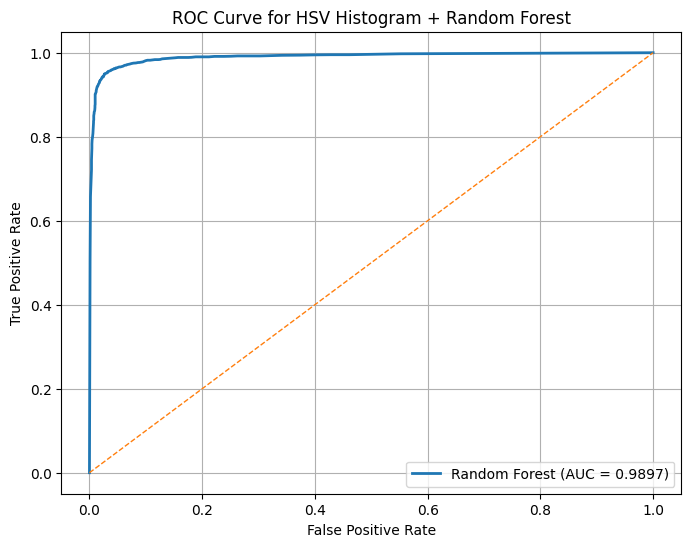

AUC: 0.9897


In [39]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve for {FEATURE_TYPE} Histogram + Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(
    os.path.join(OUTPUT_DIR, "roc_curve.png"),
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()
print(f"AUC: {roc_auc:.4f}")

### Figure 4 — Saturation Histogram Comparison

**Research question:** How do saturation distributions differ between infected and uninfected cell images?

This paper figure corresponds to Figure 4 in the accompanying manuscript. For the HSV experiment, the mean normalized saturation histogram for each class illustrates the color-distribution differences that contribute strongly to classification. It is interpretive and does not alter model training.

Building saturation histograms:   0%|          | 0/27558 [00:00<?, ?it/s]

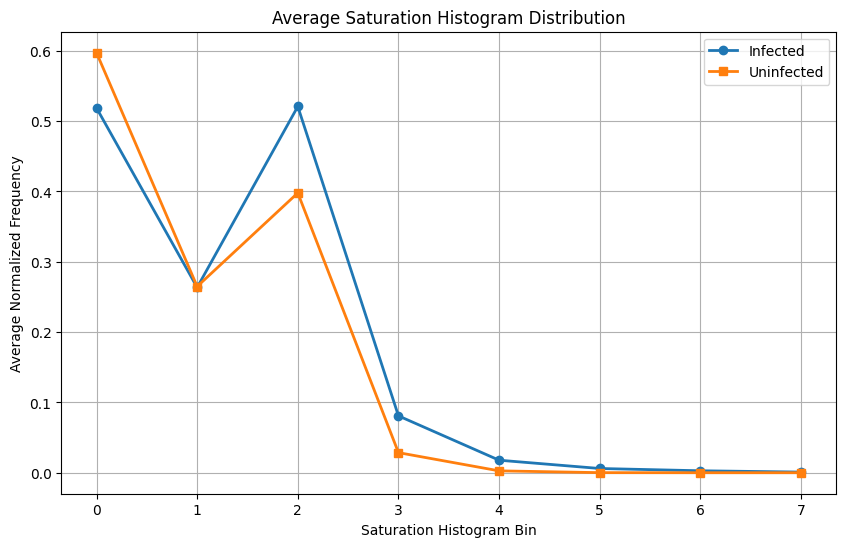

In [40]:
def mean_saturation_histograms(infected_paths, uninfected_paths):
    """Return class-wise means of normalized saturation histograms."""
    class_histograms = {1: [], 0: []}
    image_records = (
        [(path, 1) for path in infected_paths]
        + [(path, 0) for path in uninfected_paths]
    )
    for path, label in tqdm(image_records, desc="Building saturation histograms"):
        image = preprocess_image(path)
        if image is None:
            continue
        saturation = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)[:, :, 1]
        histogram = cv2.calcHist(
            [saturation], [0], None, [NUM_BINS], [0, 256]
        )
        class_histograms[label].append(
            cv2.normalize(histogram, histogram).flatten()
        )
    return np.mean(class_histograms[1], axis=0), np.mean(class_histograms[0], axis=0)


infected_mean, uninfected_mean = mean_saturation_histograms(
    infected_images, uninfected_images
)
histogram_bins = np.arange(NUM_BINS)
plt.figure(figsize=(10, 6))
plt.plot(histogram_bins, infected_mean, marker="o", linewidth=2, label="Infected")
plt.plot(histogram_bins, uninfected_mean, marker="s", linewidth=2, label="Uninfected")
plt.xlabel("Saturation Histogram Bin")
plt.ylabel("Average Normalized Frequency")
plt.title("Average Saturation Histogram Distribution")
plt.xticks(histogram_bins)
plt.legend()
plt.grid(True)
plt.savefig(
    os.path.join(OUTPUT_DIR, "saturation_histogram_comparison.png"),
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()

## 19. Cross-Validation

**Research question:** Does the model generalize consistently across multiple data partitions?

Five-fold cross-validation evaluates whether performance is stable across different partitions of the complete feature dataset. The mean estimates generalization performance, while the standard deviation measures variation between folds.

In [41]:
cv_scores = cross_val_score(
    model, X, y, cv=CV_FOLDS, scoring="accuracy", n_jobs=-1
)

for fold_index, score in enumerate(cv_scores, start=1):
    print(f"Fold {fold_index}: {score * 100:.2f}%")
print(f"Mean CV accuracy: {cv_scores.mean() * 100:.2f}%")
print(f"CV standard deviation: {cv_scores.std() * 100:.2f}%")

Fold 1: 95.92%
Fold 2: 96.12%
Fold 3: 96.55%
Fold 4: 96.01%
Fold 5: 95.70%
Mean CV accuracy: 96.06%
CV standard deviation: 0.28%


## 20. Feature Importance

**Research question:** Which histogram bins contribute most strongly to classification performance?

Random Forest impurity-based feature importance estimates how much each histogram bin contributes to reducing uncertainty across the fitted trees. The ranking identifies the color ranges most useful to the classifier.

Top 10 most important features:
S_bin_3: 0.2829
S_bin_5: 0.1953
S_bin_4: 0.1626
S_bin_6: 0.0654
S_bin_2: 0.0594
V_bin_5: 0.0289
H_bin_4: 0.0232
H_bin_5: 0.0227
H_bin_0: 0.0201
S_bin_0: 0.0186


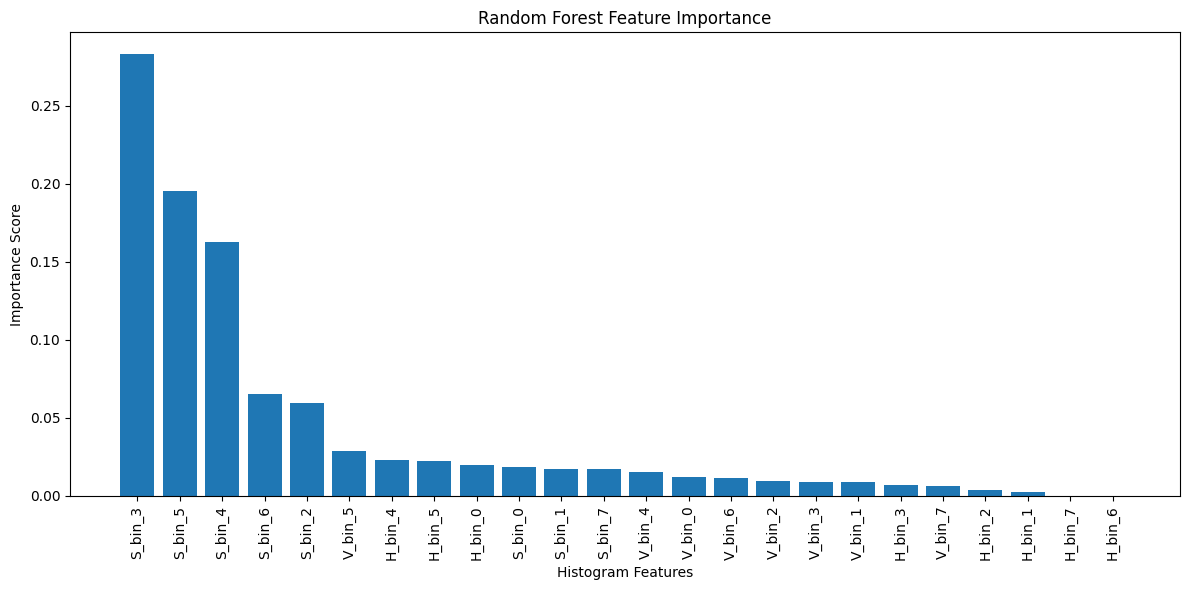

In [42]:
importances = model.feature_importances_
importance_order = np.argsort(importances)[::-1]
sorted_features = [feature_names[index] for index in importance_order]
sorted_importances = importances[importance_order]

print("Top 10 most important features:")
for name, importance in zip(sorted_features[:10], sorted_importances[:10]):
    print(f"{name}: {importance:.4f}")

plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances)
plt.xticks(rotation=90)
plt.xlabel("Histogram Features")
plt.ylabel("Importance Score")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "feature_importance.png"),
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()

## 21. Confusion Matrix

**Research question:** What types of classification errors does the model make on held-out cells?

The confusion matrix separates true negatives (correctly identified uninfected cells), false positives (uninfected cells predicted infected), false negatives (infected cells predicted uninfected), and true positives (correctly identified infected cells).

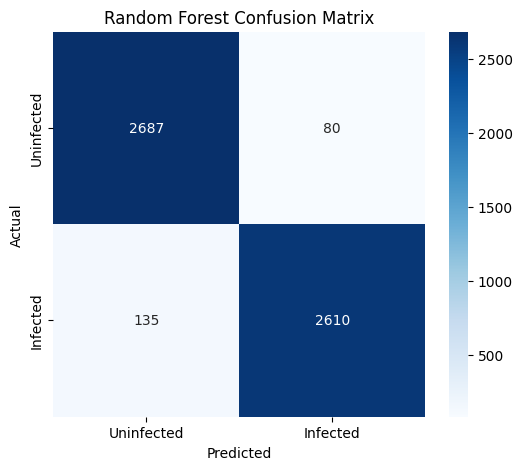

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Uninfected", "Infected"],
    yticklabels=["Uninfected", "Infected"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig(
    os.path.join(OUTPUT_DIR, "confusion_matrix.png"),
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()

## 22. Sensitivity and Specificity

Sensitivity measures the fraction of infected cells correctly detected: `TP / (TP + FN)`. Specificity measures the fraction of uninfected cells correctly rejected: `TN / (TN + FP)`.

In [44]:
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Sensitivity: 0.9508
Specificity: 0.9711


## 23. Paper Figure — PCA Visualization

**Research question:** Do the histogram features exhibit visible class structure in a two-dimensional projection?

This is a figure from the paper's exploratory analysis. Principal component analysis projects the 24-dimensional histogram features into two dimensions for visualization. PCA is not used for training or prediction and therefore does not affect classifier performance.

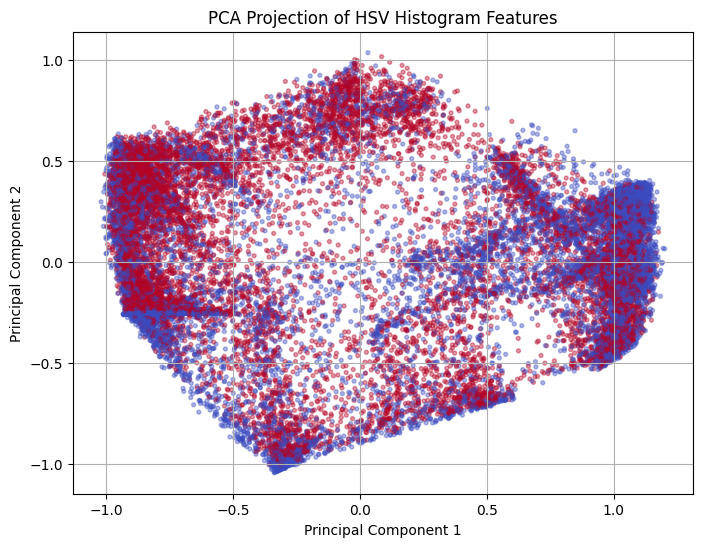

In [45]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="coolwarm",
    alpha=0.4,
    s=8,
)
plt.title(f"PCA Projection of {FEATURE_TYPE} Histogram Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.savefig(
    os.path.join(OUTPUT_DIR, f"pca_{FEATURE_TYPE.lower()}.png"),
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)
plt.show()

## 24. File Sizes

The cached feature and label arrays reduce repeated computation at the cost of local storage. The following cell reports the storage required by the files for the active experiment configuration.

In [46]:
for cache_file in [X_FILE, Y_FILE]:
    size_mb = os.path.getsize(cache_file) / (1024 ** 2)
    print(f"{cache_file}: {size_mb:.2f} MB")

./X_features_hsv_full_8bins.npy: 2.52 MB
./y_labels_hsv_full_8bins.npy: 0.21 MB


## 25. Save Outputs

The evaluation cells save the paper figures to `OUTPUT_DIR` at 300 DPI. The generated files are:

- `roc_curve.png`
- `saturation_histogram_comparison.png`
- `feature_importance.png`
- `confusion_matrix.png`
- `pca_hsv.png` for the default HSV configuration
- the matching NumPy feature and label cache files

## 26. Final Results Summary

**Feature type:** HSV  
**Classifier:** Random Forest  
**Accuracy:** 96.10%  
**AUC:** 0.9897  
**Mean five-fold CV accuracy:** 96.06%  
**Training time:** 15.71 seconds in the recorded run  
**Feature dimension:** 24  
**Dataset:** 27,558 images  
**Sensitivity:** 0.9508  
**Specificity:** 0.9711

These values summarize the full-dataset, eight-bin HSV experiment reported in the accompanying paper. Runtime measurements can vary with hardware, but the algorithm, parameters, data split, and evaluation procedure are fixed above.

## Future Work

The following directions extend the scientific questions investigated in the manuscript:

- External validation on the BBBC041 malaria dataset
- Robustness analysis across staining and acquisition conditions
- Additional compact histogram descriptors
- Texture features that complement color information
- Evaluation across patient-level rather than image-level partitions